# Women’s Cricket World Cup 2025 Outcome Prediction

## Overview

This project aims to predict match outcomes for the **Women’s Cricket World Cup 2025**
using historical Women’s ODI (WODI) match data.

We extract raw ball-by-ball data from [Cricsheet](https://cricsheet.org/) to build a
**PostgreSQL relational database**, which serves as the primary source of data.
We then create match-level features from the database using SQL and Python, that we use to train and evaluate supervised machine learning models.

Details of the setup and data pipeline may be found in the [README](../README.md).

For convenience, we"ve stored snapshots of features and target datasets as CSV files in the directory `../data/processed/`.

## Problem Statement

Given match-level features derived from historical ball-by-ball data,
**can we predict the outcome of a Women’s Cricket World Cup match?**

This is formulated as a **supervised learning** problem:

* **Training data:** WODIs played before WC 2025
* **Evaluation data:** Matches from the Women’s Cricket World Cup 2025

![Workflow](https://mermaid.ink/svg/pako:eNpFj01rwzAMhv-K0WWXtCRuvpzDoE0PG6xsjEFhSQ9eoiSGxA62wz6a_ve52cZ0kuB9HklnqFSNkEHTq_eq49qSh-dSElfb4k4Yq7SoeE-Oj_t7Q96wURrJMac-jU5ktbqdXzQXUsiW1NzymeyKg_P1px_Fbok8aaxFZYWSZiZ5cVQDyhtDjkr3NcmnkVxt5MBt1aH5JfOFzNUwco0z2Rfbyk7ujmc0U2_NCTxotaghs3pCDwbUA7-OcL7yJdgOBywhc22NDXdMCaW8OGzk8lWp4Y_Uamo7yBreGzdNo3sD94K3mv9HUNaoczVJC1kQsMUB2Rk-INvQdbRJGA2YH0VBEqUefLpQmK5jGrI0TMKABj4LLx58LVv9NYtp5Pt-kLI4ZglNLt_KgHjC)

## Dataset

As mentioned above, snapshots of features and target datasets are stored locally. We now take a quick look at the dataset.

In [1]:
# Imports

from pathlib import Path
import pandas as pd

In [2]:
# File Paths

processed_datadir = Path("../data/processed/").resolve()
features_csv = processed_datadir / "features.csv"
target_csv = processed_datadir / "target.csv"

In [3]:
features = pd.read_csv(
    features_csv, parse_dates=["start_date"], index_col="match_id"
    )
target = pd.read_csv(target_csv, index_col="match_id")

In [4]:
features.tail()

,hash_id,start_date,team,opponent,home_advantage,chasing_advantage,delta_team_strength
match_id,,,,,,,
1490442,3a1eb3da638f66392455d1eaf8d23d32,2025-10-30,India,Australia,1,-0.54,-0.377715
1490443,f03dd0c2940b950d1668c6744d4a59bc,2025-11-02,India,South Africa,1,0.55,0.094586
1500387,2dda2509fe7e744b61b3404a34718818,2025-09-16,Pakistan,South Africa,1,0.45,-0.488456
1500388,1fb22dc2953abda69f517b600c07d91b,2025-09-19,South Africa,Pakistan,-1,0.47,0.489961
1500389,3e3a53fd62210613aa0cf072026a74e4,2025-09-22,Pakistan,South Africa,1,-0.45,-0.492403


In [5]:
features.corr(numeric_only=True)

,home_advantage,chasing_advantage,delta_team_strength
home_advantage,1.000000,0.018925,-0.022516
chasing_advantage,0.018925,1.000000,0.094170
delta_team_strength,-0.022516,0.094170,1.000000


As we see above, our features seem to be not correlated strongly.

### Target

Let"s look at how our target variable, ie. match results.

In [6]:
freqs = target.value_counts(subset="result")
percentages = 100* freqs/len(target)
percentages

result
False    50.720461
True     49.279539
Name: count, dtype: float64

We see above that our target is distributed roughly equally between positives and negatives.

### Features

1. Home Advantage
2. Chasing Advantage
3. Team Strength Difference

Since we"re looking at ODIs, we expect home advantage to matter but not as much as the difference in team strengths.

Let"s see if our data reflects the same or not. 

In [7]:
num_cols_features = features.loc[:, "home_advantage":]
df = num_cols_features.join(other=target.result)
df.corr()

,home_advantage,chasing_advantage,delta_team_strength,result
home_advantage,1.000000,0.018925,-0.022516,0.138631
chasing_advantage,0.018925,1.000000,0.094170,-0.074962
delta_team_strength,-0.022516,0.094170,1.000000,0.379596
result,0.138631,-0.074962,0.379596,1.000000


### Train / Test Split

The matches are ordered chronologically in both feature and target datasets to prevent data leakage.

We"ll train the models on all (available) WODIs before WC2025, and evaluate them on WC2025 matches.

In [8]:
cutoffs = pd.to_datetime([
    "2025-09-30", # WC 2025 start
    "2025-11-02" # WC 2025 final
])
text_cols = ["team", "opponent"]
num_cols = ["home_advantage", "chasing_advantage", "delta_team_strength"]

drop_cols = [
    col for col in features.columns
    if col not in num_cols
    ]

In [9]:
from womenswc.model_utils import train_validate_test

X_train_0, Y_train, X_test_0, Y_test = train_validate_test(features, target, cutoffs, drop_cols)

print(X_train_0.describe())
print()
print(X_test_0.shape)

       home_advantage  chasing_advantage  delta_team_strength
count      322.000000         322.000000           322.000000
mean        -0.055901           0.071770            -0.080082
std          0.908585           0.565509             0.857506
min         -1.000000          -1.000000            -8.565429
25%         -1.000000          -0.530000            -0.443545
50%          0.000000           0.455000            -0.067358
75%          1.000000           0.570000             0.363153
max          1.000000           1.000000             4.535479

(25, 3)


We notice a few things right off the bat.

- Training Set - 322 matches
- Test Set - 25 matches
- `home_advantage` and `chasing_advantage` lie in the range (-1, 1), while `delta_team_strength` varies roughly between -8.5 and 4.5. So we would want to standardize our table.

**Note:** To prevent data leakage, we standardize the dataset after splitting into train and test sets. We"ll take advantage of sklearn"s `Column Transormer` to transform only the columns we want.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

pipeline = ColumnTransformer([
    ("stndscale", StandardScaler(), num_cols)
])

In [11]:
X_train = pipeline.fit_transform(X_train_0)
X_test = pipeline.fit_transform(X_test_0)
X_train.shape

(322, 3)

### Scatter Plot of features

Let's plot a scatter chart of the continous features - `chasing_strength` and `delta_team_strength` and see if we can find
some insight.

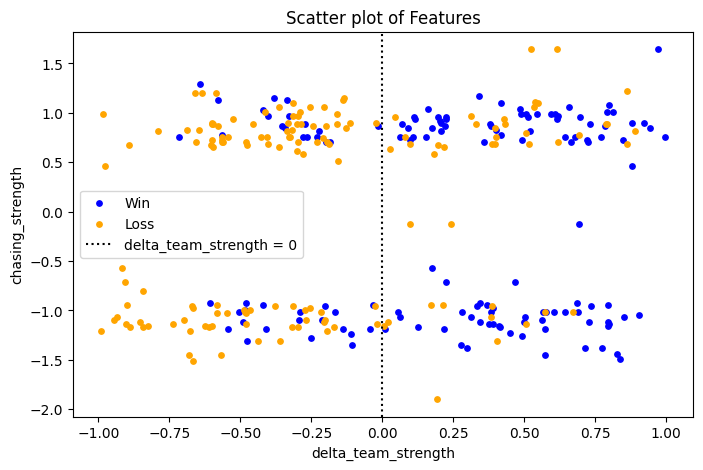

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
cmap = {
    True: "blue",
    False: "orange"
    }
labels = {
    "blue": "Win",
    "orange": "Loss"
}
X = X_train[:, 2] # Delta Team Strength
Y = Y_train

# Clip extreme values
clipping = (X > -1) & (X < 1)
X_0 = X[clipping]
Y_0 = Y[clipping]

X_1 = X_train[:, 1][clipping] # Chasing Strength

for key, color in cmap.items():
    ax.scatter(
        X_0[Y_0 == key],
        X_1[Y_0 == key],
        label=labels[color],
        c=color,
        s=15
)
plt.axvline(0, color="black", linestyle=":", label="delta_team_strength = 0")
plt.xlabel("delta_team_strength")
plt.ylabel("chasing_strength")
plt.title("Scatter plot of Features")
plt.legend()
plt.show()

We can see that to the left of the black dotted line, more data points have loss as result while
to the right, more data points have win. This indicates that `delta_team_strength` can provide a decision threshold.

## Models

We'll train and evaluate three models and compare their performance:

1. Baseline Classifier - Predict win if `delta_team_strength > 0`.
2. Logistic Regression
3. Random Forest

### 1. Baseline Classifier

We already saw that `delta_team_strength` contains a strong signal. That means we can start with a simple baseline classifier - predict that the stronger team wins.

In [13]:
from womenswc.model_utils import cross_validation

In [14]:
from sklearn.base import BaseEstimator
import numpy as np

class BaseLineClassifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X: np.typing.NDArray):
        return X > 0

For cross-validation, we're using expanding window folds to prevent data leakage. For more details, you may find the code in `src/womenswc`.

In [15]:
model_input = BaseLineClassifier()

results_baseline = cross_validation(
    model_input,
    X_train_0.iloc[:, 2],
    Y_train,
    min_first=92,
    n_parts=14
)
results = {"Baseline": results_baseline}

In [16]:
from womenswc.metrics import accuracy, precision_recall

accuracy_values = np.array([
    accuracy(confusion_matrix) for confusion_matrix in results["Baseline"]["CV_matrices"]
])
results["Baseline"]["CV_accuracy"] = accuracy_values

print("Accuracy Values - Baseline Classifier\n")
print(results["Baseline"]["CV_accuracy"])
print("Mean Accuracy:", accuracy_values.mean())

Accuracy Values - Baseline Classifier

[0.73913043 0.69565217 0.86956522 0.73913043 0.65217391 0.65217391
 0.69565217 0.91304348 0.69565217]
Mean Accuracy: 0.7391304347826088


### 2. Logistic Regression

We"ll train a logistic regression model as a baseline to see if our features do contain some predictive signals.

In [17]:
from sklearn.linear_model import LogisticRegression

# Optimize regularization hyperparameter
C_values = [0.1, 1, 10]

for C in C_values:
    model_input = LogisticRegression(
    solver="lbfgs", max_iter=1000, C=C
    )
    results_lgr = cross_validation(
        model_input, X_train, Y_train, min_first=92, n_parts=14, predict_prob=True
    )
    print(f"{C=} -->", np.mean(results_lgr["CV_log_loss"]), np.std(results_lgr["CV_log_loss"]))


C=0.1 --> 0.5771988853809131 0.049243811763518254
C=1 --> 0.5434968028890039 0.07503238994832724
C=10 --> 0.5388325808212782 0.08052314809327503


We can see that C = 1 is a good choice for our regularization hyperparameter.

In [18]:
# Cross-Validation

model_input = LogisticRegression(
    solver="lbfgs", max_iter=1000, C=1
    )
results["LogisticRegression"] = cross_validation(
    model_input, X_train, Y_train, min_first=92, n_parts=14, predict_prob=True
)
accuracy_values = np.array([
    accuracy(confusion_matrix) for confusion_matrix in results["LogisticRegression"]["CV_matrices"]
])

print("Accuracy Values - Logistic Regression\n")
print(accuracy_values)
print("Mean Accuracy:", accuracy_values.mean())

Accuracy Values - Logistic Regression

[0.73913043 0.73913043 0.82608696 0.73913043 0.69565217 0.65217391
 0.65217391 0.95652174 0.65217391]
Mean Accuracy: 0.7391304347826088


**Comparision**

It's immediate from a quick glance at accuracy values for Baseline Classifier and Logistic Regression that
`delta_team_strength` they both perform similarly. This isn't surprising because logistic regression basically learns
a threshold decision rule on `delta_team_strength`.

We can confirm this by looking at the plot below which reveals a decision boundary at `delta_team_strength ~ 0`.

#### Decision Boundary

In [19]:
log_reg = LogisticRegression(
    solver="lbfgs", max_iter=1000, C=1
    )
X = X_train[:, 2:]
start = int(X.min())
stop = int(X.max()) + 1
y = Y_train
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

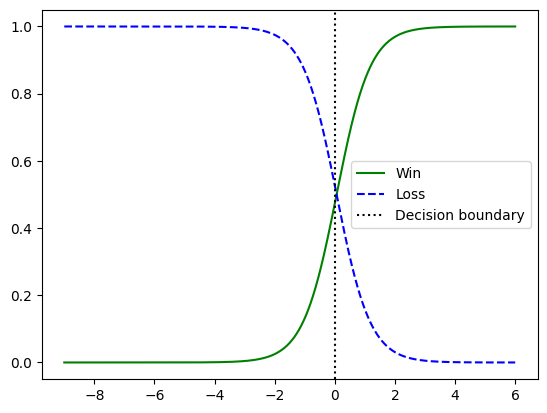

In [20]:
# Decision Boundary
X_new = np.linspace(start, stop, 10000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Win")
plt.plot(X_new, y_proba[:, 0], "b--", label="Loss")
plt.axvline(0, color="black", linestyle=":", label="Decision boundary")
plt.legend()
plt.show()

In [21]:
print("delta_team_strength = 0.060:", log_reg.predict([[0.060]]))
print("delta_team_strength = 0.061:", log_reg.predict([[0.061]]))

delta_team_strength = 0.060: [False]
delta_team_strength = 0.061: [ True]


We see clearly that the decision boundary lies very close to 0, somewhere between 0.060 and 0.061.

### 3. Random Forest

We'll try a non-linear model this time.

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model_input = RandomForestClassifier(n_estimators=100, random_state=1712, bootstrap=True)
results["RandomForest"] = cross_validation(
    model_input, X_train, Y_train, min_first=92, n_parts=14
)

In [24]:
accuracy_values = np.array([
    accuracy(confusion_matrix) for confusion_matrix in results["RandomForest"]["CV_matrices"]
])

print("Accuracy Values - Random Forest\n")
print(accuracy_values)
print("Mean Accuracy:", accuracy_values.mean())

Accuracy Values - Random Forest

[0.65217391 0.73913043 0.7826087  0.60869565 0.69565217 0.65217391
 0.47826087 0.7826087  0.65217391]
Mean Accuracy: 0.6714975845410628


Interestingly, we observe that Random Forest performs slightly worse than our Baseline Classifier and Logistic Regression models.

This might be due to overfitting and high variance since our training set is small, with just 322 data points.

## Predictions

We'll now look at how well our models perform on the World Cup 2025 matches, i.e. the test dataset.

### 1. Baseline Classifier

We begin with our Baseline Classifier.

In [25]:
from womenswc.metrics import accuracy, precision_recall
from sklearn.metrics import confusion_matrix

base_clf = BaseLineClassifier()
base_clf.fit(X_train[:, 2])

BaseLineClassifier()

In [26]:
Y_pred = base_clf.predict(X_test[:, 2])
results["Baseline"]["Confusion_Matrix"] = confusion_matrix(Y_test, Y_pred)
results["Baseline"]["Accuracy"] = accuracy(conf_matrix=results["Baseline"]["Confusion_Matrix"])
prec, rec = precision_recall(conf_matrix=results["Baseline"]["Confusion_Matrix"])
results["Baseline"]["Precision"] = prec
results["Baseline"]["Recall"] = rec
f1_score = 2 * prec * rec / (prec + rec)
results["Baseline"]["F1_Score"] = f1_score

In [27]:
print("Accuracy:", results["Baseline"]["Accuracy"])
print("Precision:", np.round(results["Baseline"]["Precision"], 2))
print("Recall:", np.round(results["Baseline"]["Recall"], 2))
print("F1-Score:", np.round(results["Baseline"]["F1_Score"], 2))

Accuracy: 0.88
Precision: [0.85 0.92]
Recall: [0.92 0.85]
F1-Score: [0.88 0.88]


#### Performance Metrics

- Accuracy: 88%
- Precision: 0.85, 0.92
- Recall: 0.92, 0.85
- F1-Score: 0.88, 0.88

---

### 2. Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
log_reg_clf = LogisticRegression(solver="lbfgs", max_iter=1000, C=1)
log_reg_clf.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Coefficients

In [29]:
np.round(log_reg_clf.coef_, 3)

array([[ 0.283, -0.272,  1.786]])

We can notice right away that the team strength differential contains the strongest signal, while home advantage contains a weak postive signal.
But something slightly unexpected happens is that chasing advantage contains a weak negative signal. So, what we're seeing is that batting first seems to be better than chasing.

#### Confusion Matrix

We'll first take a look at the confusion matrix.

In [30]:
Y_pred = log_reg_clf.predict(X_test)

results["LogisticRegression"]["Confusion_Matrix"] = confusion_matrix(Y_test, Y_pred)
results["LogisticRegression"]["Accuracy"] = accuracy(conf_matrix=results["LogisticRegression"]["Confusion_Matrix"])
prec, rec = precision_recall(conf_matrix=results["LogisticRegression"]["Confusion_Matrix"])
results["LogisticRegression"]["Precision"] = prec
results["LogisticRegression"]["Recall"] = rec
f1_score = 2 * prec * rec / (prec + rec)
results["LogisticRegression"]["F1_Score"] = f1_score

In [31]:
print("Accuracy:", results["LogisticRegression"]["Accuracy"])
print("Precision:", np.round(results["LogisticRegression"]["Precision"], 2))
print("Recall:", np.round(results["LogisticRegression"]["Recall"], 2))
print("F1-Score:", np.round(results["LogisticRegression"]["F1_Score"], 2))

Accuracy: 0.88
Precision: [0.85 0.92]
Recall: [0.92 0.85]
F1-Score: [0.88 0.88]


#### ROC Curve

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

probs = log_reg_clf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(Y_test, probs[:, 1])
auc = roc_auc_score(Y_test, probs[:, 1])
results["LogisticRegression"]["AUC"] = auc

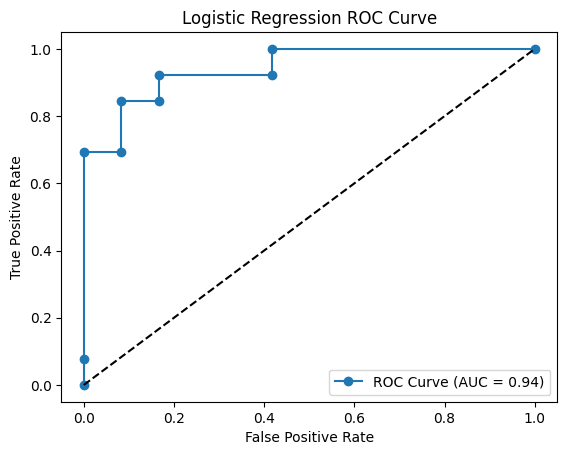

In [33]:
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})", marker="o")
plt.plot([0, 1], [0, 1], "k--") # Diagonal diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

#### Performance Metrics

- Accuracy: 88%
- Precision: 0.85, 0.92
- Recall: 0.92, 0.85
- F1-Score: 0.88, 0.88
- ROC AUC: 0.94

---

### 3. Random Forest

In [34]:
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=1712, bootstrap=True)
rnd_clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
Y_pred = rnd_clf.predict(X_test)

results["RandomForest"]["Confusion_Matrix"] = confusion_matrix(Y_test, Y_pred)
results["RandomForest"]["Accuracy"] = accuracy(conf_matrix=results["RandomForest"]["Confusion_Matrix"])

prec, rec = precision_recall(conf_matrix=results["RandomForest"]["Confusion_Matrix"])
results["RandomForest"]["Precision"] = prec
results["RandomForest"]["Recall"] = rec

f1_score = 2 * prec * rec / (prec + rec)
results["RandomForest"]["F1_Score"] = f1_score

In [36]:
print("Accuracy:", results["RandomForest"]["Accuracy"])
print("Precision:", np.round(results["RandomForest"]["Precision"], 2))
print("Recall:", np.round(results["RandomForest"]["Recall"], 2))
print("F1-Score:", np.round(results["RandomForest"]["F1_Score"], 2))

Accuracy: 0.88
Precision: [0.85 0.92]
Recall: [0.92 0.85]
F1-Score: [0.88 0.88]


#### Performance Metrics

- Accuracy: 88%
- Precision: 0.85, 0.92
- Recall: 0.92, 0.85
- F1-Score: 0.88, 0.88

## Model Comparison

We'll quickly summarize the model performance comparison in a table below:

| Model               | CV Mean Accuracy | CV Mean Log Loss | Accuracy | F1-Score |
|---------------------|------------------|------------------|----------|----------|
| Baseline Classifier | 74%              | -                | 88%      | 0.88     |
| Logistic Regression | 74%              | 0.54             | 88%      | 0.88     |
| Random Forest       | 67%              | -                | 88%      | 0.88     |

We clearly see that our models perform same when evaluated on our test set, i.e. World Cup 2025 matches. This could be because,
- The feature `delta_team_strength` contains reasonably strong predictive signal.
- Test set and features list are too small to give us any advantage of using a more complex model.

## Conclusion

Across cross-validation folds, logistic regression performs similarly
to the naive baseline classifier. This occurs because logistic regression
essentially learns a threshold decision rule on the `delta_team_strength`
feature.

Random Forest does not improve predictive performance, suggesting that
the relationship between the features and match outcome is largely linear.

These results indicate that relative team strength is the dominant factor
in determining match outcomes in Women’s ODIs.